<a href="https://colab.research.google.com/github/queleandrade/estatistica_ciencias_dados---Mestrado/blob/main/cod_grafs_longitudinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tradução R → Python (Estudos Longitudinais)
Baseado no arquivo fornecido.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:

# Ajuste o caminho no Colab
df = pd.read_excel('/content/banco3_modulo1.xlsx')
df.head()


,Ind,t12,t14,t16,t18,t20,t22,t24,t26
0,1,54.1,65.4,75.1,87.9,98.0,108.7,124.2,131.3
1,2,91.7,104.0,119.2,133.1,145.4,156.5,167.2,176.8
2,3,64.2,81.0,91.5,106.9,117.1,127.7,144.2,154.9
3,4,70.3,80.0,90.0,102.6,101.2,120.4,130.9,137.1
4,5,68.3,77.2,84.2,96.2,104.1,114.0,123.0,132.0


In [3]:

df.describe()


,Ind,t12,t14,t16,t18,t20,t22,t24,t26
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,8.000000,69.606667,77.653333,87.226667,98.193333,106.893333,116.366667,125.120000,133.593333
std,4.472136,15.155455,16.036782,18.556303,19.973606,19.936057,22.579595,23.632006,26.560994
min,1.000000,43.900000,48.100000,58.300000,68.600000,78.200000,75.100000,79.000000,77.000000
25%,4.500000,56.250000,64.550000,72.600000,84.400000,95.200000,104.400000,111.700000,119.650000
50%,8.000000,70.300000,80.800000,90.000000,102.600000,104.100000,115.600000,124.200000,134.200000
75%,11.500000,79.800000,88.250000,97.050000,108.450000,118.950000,131.400000,142.850000,153.200000
max,15.000000,91.700000,104.000000,119.200000,133.100000,145.400000,156.500000,167.200000,176.800000


In [4]:

# Transformar para formato longo
df_long = df.melt(id_vars=['Ind'], var_name='Tempo', value_name='Peso')
df_long.head()


,Ind,Tempo,Peso
0,1,t12,54.1
1,2,t12,91.7
2,3,t12,64.2
3,4,t12,70.3
4,5,t12,68.3


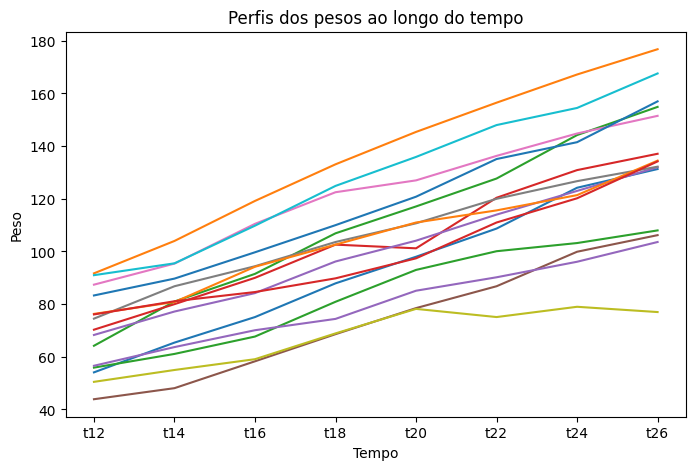

In [5]:

# Perfis individuais
plt.figure(figsize=(8,5))
for key, grp in df_long.groupby('Ind'):
    plt.plot(grp['Tempo'], grp['Peso'])
plt.title('Perfis dos pesos ao longo do tempo')
plt.xlabel('Tempo')
plt.ylabel('Peso')
plt.show()


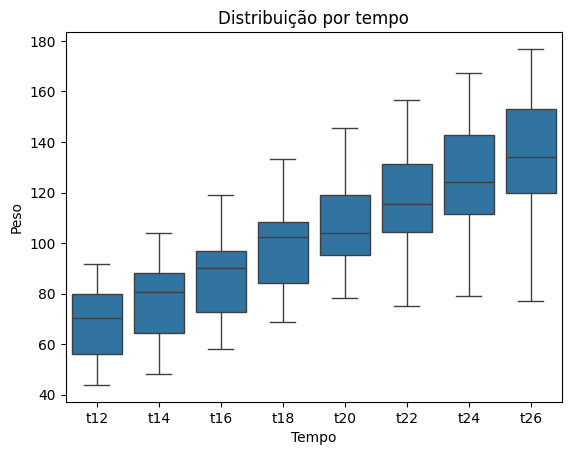

In [6]:

sns.boxplot(x='Tempo', y='Peso', data=df_long)
plt.title('Distribuição por tempo')
plt.show()


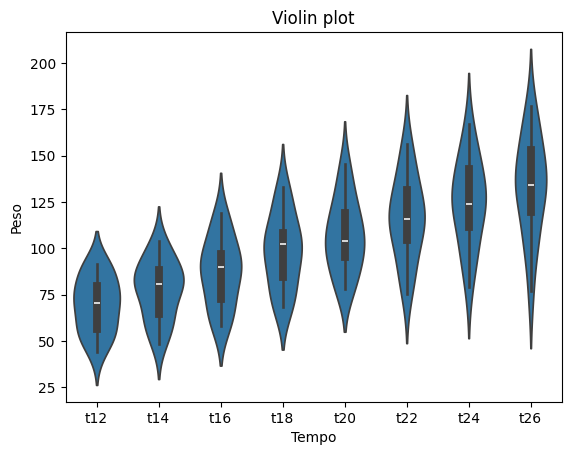

In [7]:

sns.violinplot(x='Tempo', y='Peso', data=df_long)
plt.title('Violin plot')
plt.show()


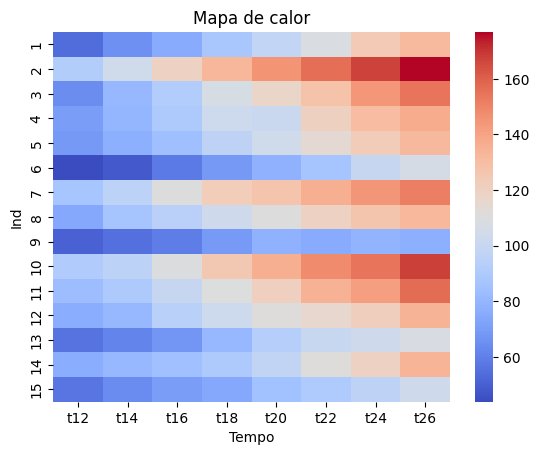

In [8]:

pivot = df_long.pivot(index='Ind', columns='Tempo', values='Peso')
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Mapa de calor')
plt.show()


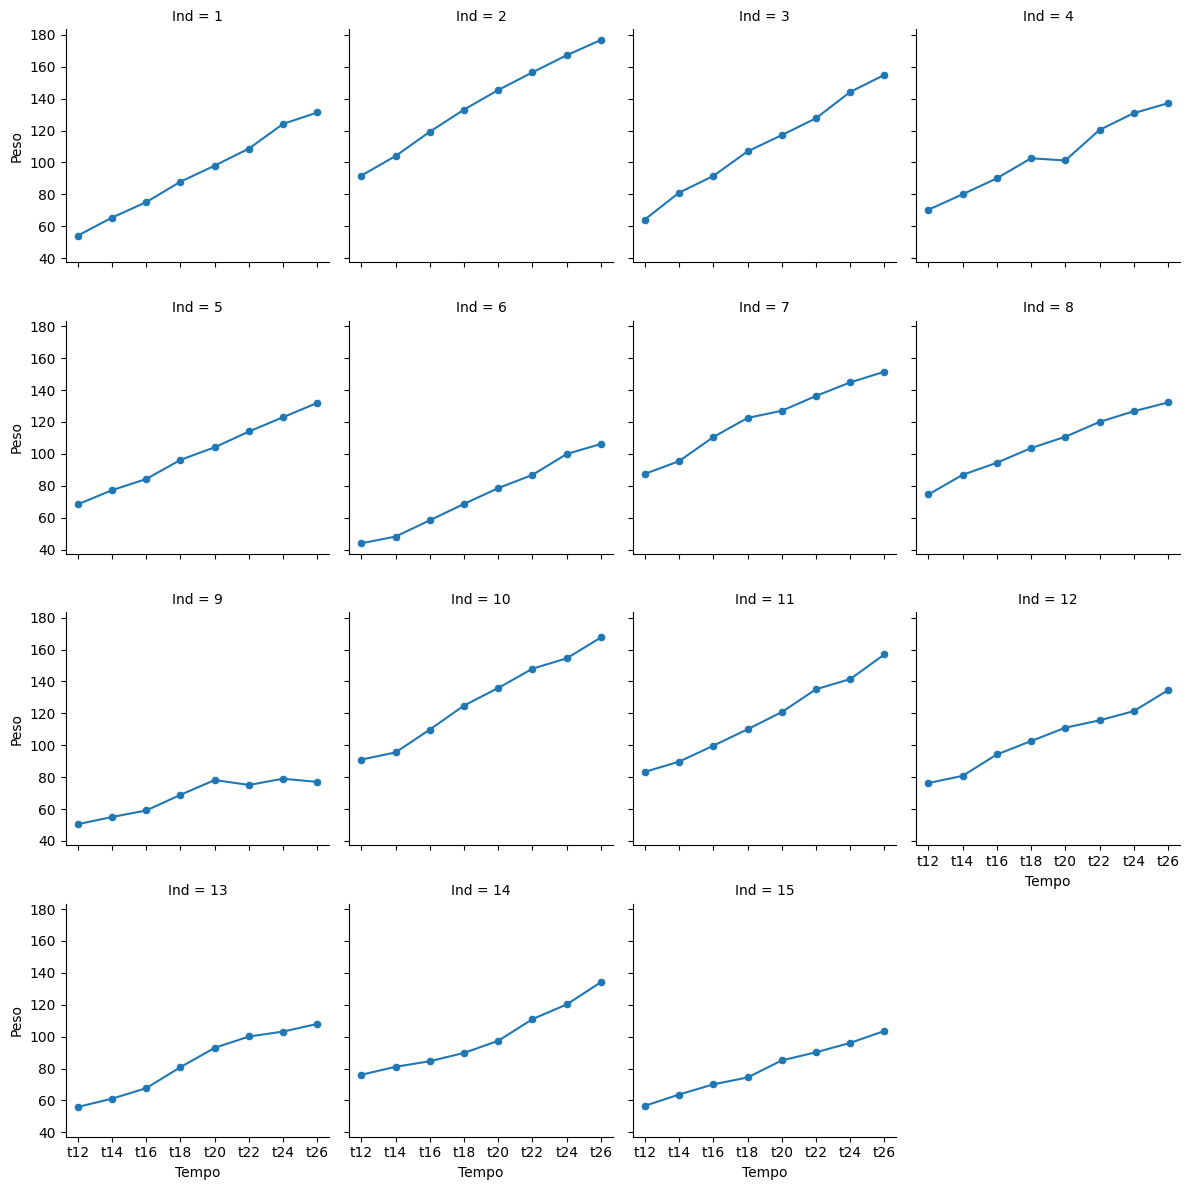

In [9]:

g = sns.FacetGrid(df_long, col='Ind', col_wrap=4)
g.map_dataframe(sns.lineplot, x='Tempo', y='Peso')
g.map_dataframe(sns.scatterplot, x='Tempo', y='Peso')
plt.show()


In [10]:

import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

anova = AnovaRM(df_long, depvar='Peso', subject='Ind', within=['Tempo'])
anova.fit()


In [11]:

# Friedman (não paramétrico)
# reorganizar dados por tempo
groups = [group['Peso'].values for name, group in df_long.groupby('Tempo')]
stats.friedmanchisquare(*groups)


FriedmanchisquareResult(statistic=np.float64(103.0888888888889), pvalue=np.float64(2.4806740128103274e-19))